In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for visualizations
sns.set(style='darkgrid')




In [2]:
# Load dataset
df = pd.read_csv('netflix_titles.csv')

In [3]:
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
# 1. Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [5]:
# 2. Remove duplicates
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [6]:
# 3. Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['date_added'].head()

,date_added
0,2021-09-25
1,2021-09-24
2,2021-09-24
3,2021-09-24
4,2021-09-24


In [7]:
# 4. Fill missing values for date_added with mode
df['date_added'].fillna(df['date_added'].mode()[0], inplace=True)

<ipython-input-7-5b61571674f2>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['date_added'].fillna(df['date_added'].mode()[0], inplace=True)


In [8]:
df['date_added'].isnull().sum()

np.int64(0)

In [12]:
# 5. Fill nulls in director, cast, country with 'Unknown'
df[['director', 'cast', 'country']] = df[['director', 'cast', 'country']].fillna('Unknown')
df['rating'].fillna("Not Rated", inplace=True)
df['duration'].fillna("Unknown", inplace=True)
df[['director', 'cast', 'country']].isnull().sum()

<ipython-input-12-ca8f7f3552d6>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rating'].fillna("Not Rated", inplace=True)
<ipython-input-12-ca8f7f3552d6>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

,0
director,0
cast,0
country,0


In [10]:
# 6. Extract year_added and month_added
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
# No need to access 'dt' again as 'year_added' and 'month_added' are already integers
print(df['month_added'])  # Print the 'month_added' Series
print(df['year_added'])  # Print the 'year_added' Series

0        9
1        9
2        9
3        9
4        9
        ..
8802    11
8803     7
8804    11
8805     1
8806     3
Name: month_added, Length: 8807, dtype: int32
0       2021
1       2021
2       2021
3       2021
4       2021
        ... 
8802    2019
8803    2019
8804    2019
8805    2020
8806    2019
Name: year_added, Length: 8807, dtype: int32


In [11]:
# 7. Strip and lowercase string columns for consistency
string_cols = ['type', 'title', 'director', 'cast', 'country', 'rating', 'listed_in']
for col in string_cols:
    df[col] = df[col].str.strip().str.lower()

print(df[string_cols].head())

      type                  title         director  \
0    movie   dick johnson is dead  kirsten johnson   
1  tv show          blood & water          unknown   
2  tv show              ganglands  julien leclercq   
3  tv show  jailbirds new orleans          unknown   
4  tv show           kota factory          unknown   

                                                cast        country rating  \
0                                            unknown  united states  pg-13   
1  ama qamata, khosi ngema, gail mabalane, thaban...   south africa  tv-ma   
2  sami bouajila, tracy gotoas, samuel jouy, nabi...        unknown  tv-ma   
3                                            unknown        unknown  tv-ma   
4  mayur more, jitendra kumar, ranjan raj, alam k...          india  tv-ma   

                                           listed_in  
0                                      documentaries  
1    international tv shows, tv dramas, tv mysteries  
2  crime tv shows, international tv shows

<ipython-input-13-c21f4a484ee5>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', palette='Set2')


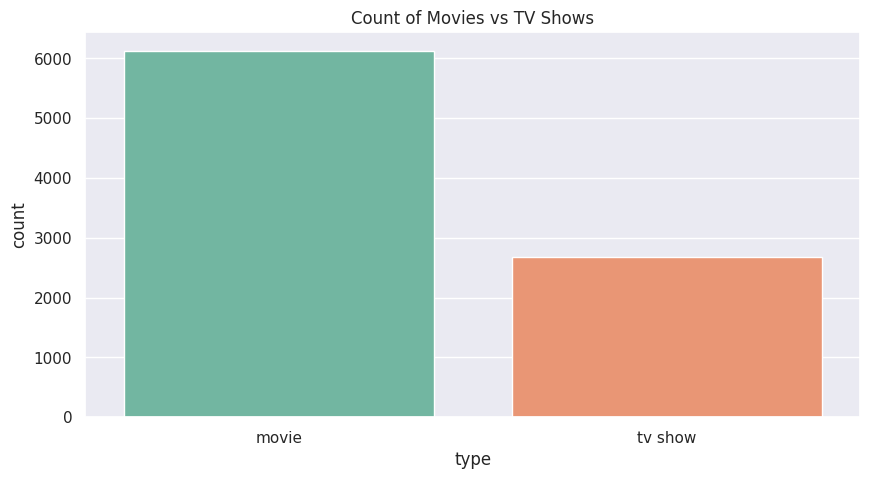

In [13]:
# ------------------------ #
#       VISUALIZATION      #
# ------------------------ #

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='type', palette='Set2')
plt.title('Count of Movies vs TV Shows')
plt.show()

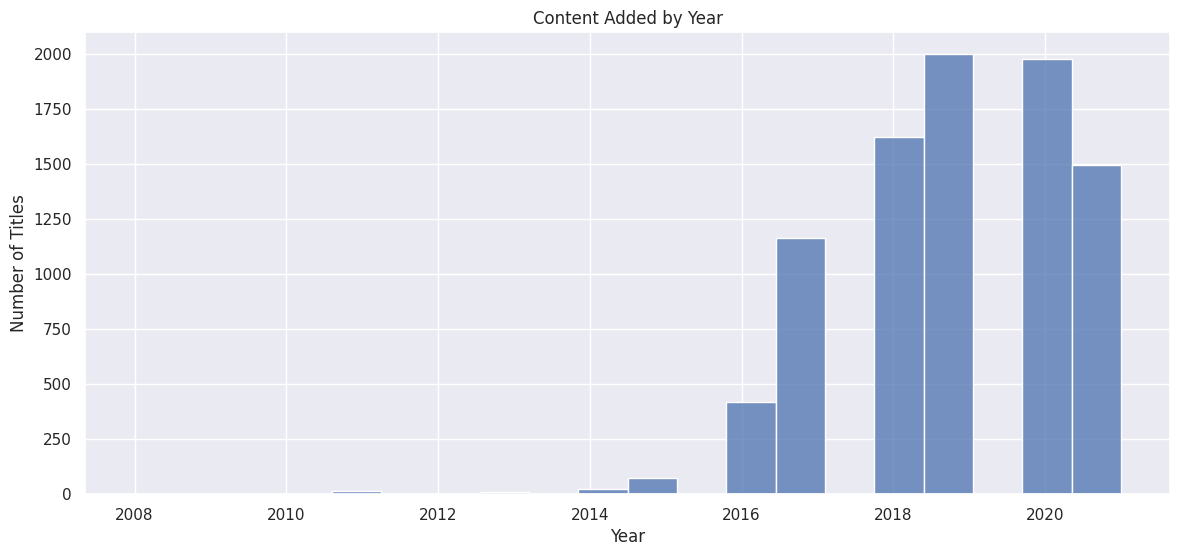

In [14]:
# Number of releases per year
plt.figure(figsize=(14, 6))
sns.histplot(df['year_added'].dropna(), bins=20, kde=False)
plt.title("Content Added by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

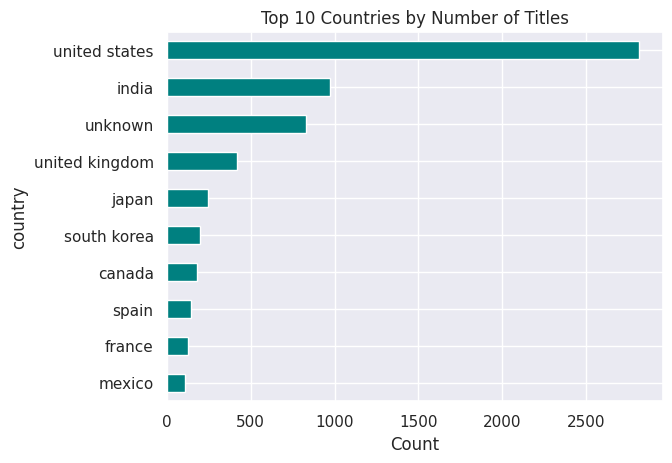

In [15]:
# Top 10 countries with most content
top_countries = df['country'].value_counts().head(10)
top_countries.plot(kind='barh', color='teal')
plt.title("Top 10 Countries by Number of Titles")
plt.xlabel("Count")
plt.gca().invert_yaxis()
plt.show()


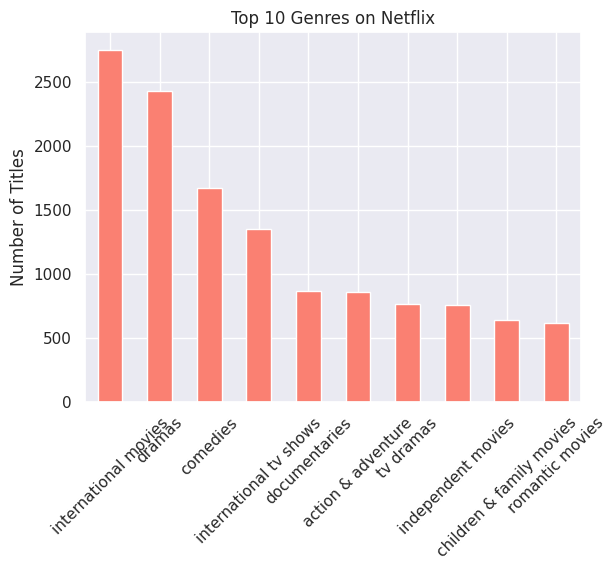

In [17]:
# Genre Distribution
all_genres = df['listed_in'].str.split(', ', expand=True).stack()
top_genres = all_genres.value_counts().head(10)
top_genres.plot(kind='bar', color='salmon')
plt.title("Top 10 Genres on Netflix")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()
